> **Repository note.** Paper Experiment B: nested same-context diagnostic/control update.
> This notebook is preserved with executed outputs from the research run. Large embedding caches and third-party datasets are intentionally not bundled. See `REPRODUCIBILITY.md` at the repository root.


# Semantic Disambiguation Geometry V4
## Nested Context Updates: Preserve, Compress, or Enrich?

V3 established a robust empirical pattern: sense-diagnostic evidence consistently increases **between-sense differentiation**, while within-sense geometry depends on architecture and depth.

V4 asks the stronger mechanistic question:

\[
\boxed{
\textbf{When sense information becomes more accessible,}
\quad
\textbf{what happens to structure already present in the representation?}
}
\]

The central change from V3 is a **nested intervention**. For the same occurrence:

\[
h_0 = E(w,C_{\text{base}}),\qquad
h_+ = E(w,C_{\text{base}}\cup\{c_{\text{diagnostic}}\}),\qquad
h_{\text{ctrl}} = E(w,C_{\text{base}}\cup\{c_{\text{control}}\}).
\]

Every post-update representation contains the **same pre-existing base context**. This makes preservation/compression testable rather than inferred from a scalar cloud radius.

## What this notebook measures

One coherent experiment, several aligned diagnostics:

- **Sense accessibility:** linear probe, NLL, entropy, and null-adjusted usable information.
- **Old-context accessibility:** reconstruct the already-visible base context from the target-token representation.
- **Coordinate retention:** train the old-context decoder only on BASE, then transfer it unchanged to post-cue states.
- **Structural preservation:** CKA and RSA between paired pre-cue/post-cue representations.
- **Exact covariance geometry:** \(S_T=S_W+S_B\), with dimensionless sense-structure ratios.
- **Variance redistribution:** \(W_\parallel\) vs \(W_\perp\) relative to a learned sense subspace.
- **Update direction:** fraction of \(\delta=h_{post}-h_0\) lying in the sense subspace.
- **Eigenspectrum:** whether within-sense variance is removed/added in a few directions or broadly.

All main effects compare DIAGNOSTIC against the **mean of three side/distance-matched random controls**, and confidence intervals resample lexical items, not token pairs.

## Falsifiable hypotheses

These are *hypotheses*, not model personalities assumed in advance.

**BERT compression hypothesis**

\[
\Delta I_{sense}>0,\qquad \Delta W_\perp<0.
\]

**RoBERTa preservation hypothesis**

\[
\Delta I_{sense}>0,\qquad \operatorname{CKA}(H_0,H_+)\text{ high},\qquad \Delta W_\perp\approx0.
\]

**DeBERTa enrichment hypothesis**

\[
\Delta I_{sense}>0,\qquad \Delta W_\perp>0,
\]

but call this enrichment only if old-context accessibility is maintained/improved.

If the labels flip across layers/evidence levels, prefer a **layer × evidence trajectory** story.

In [1]:
# Kaggle / Colab setup
!pip -q install "datasets>=2.18,<4" "transformers>=4.43,<5" accelerate scipy scikit-learn pandas pyarrow tqdm sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


In [2]:
import gc
import math
import json
import random
import hashlib
import warnings
import shutil
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import balanced_accuracy_score, f1_score, log_loss, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, wilcoxon

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


# 1. Configuration

`PROFILE="resource"` is the intended run. The encoder workload is smaller than V3: 3 base sizes × (BASE + DIAGNOSTIC + 3 controls) = **15 variants/example**, and one forward pass yields layers 4/8/12. Caches are restart-safe.

In [3]:
PROFILE = "resource"  # "smoke" or "resource"
DATASET_ID = "kiamehr74/CoarseWSD-20"

ALL_WORDS = [
    "apple", "arm", "bank", "bass", "bow",
    "chair", "club", "crane", "deck", "digit",
    "hood", "java", "mole", "pitcher", "pound",
    "seal", "spring", "square", "trunk", "yard",
]

MAIN_MODELS = [
    "bert-base-uncased",
    "roberta-base",
    "microsoft/deberta-v3-base",
]

LAYERS = [4, 8, 12]
BASE_SIZES = [2, 4, 8]
CONTROL_SEEDS = [11, 47, 83]
BASE_SEED = 2026

if PROFILE == "smoke":
    WORDS = ["bank", "bass", "java", "spring"]
    MODELS = ["bert-base-uncased"]
    MAX_TRAIN_PER_SENSE = 60
    MAX_TEST_PER_SENSE = 35
    TFIDF_SVD_DIM = 24
    WHITEN_DIM = 64
    BOOTSTRAP_ITERS = 1000
    EIGEN_LAYERS = [12]
else:
    WORDS = ALL_WORDS
    MODELS = MAIN_MODELS
    MAX_TRAIN_PER_SENSE = 110
    MAX_TEST_PER_SENSE = 70
    TFIDF_SVD_DIM = 64
    WHITEN_DIM = 256
    BOOTSTRAP_ITERS = 5000
    # Eigenspectrum is secondary and CPU-heavy; final layer is enough for the first V4 run.
    EIGEN_LAYERS = [12]

MIN_TRAIN_PER_SENSE = 15
MIN_TEST_PER_SENSE = 8
MAX_WORDS = 80
TOKENIZER_MAX_LENGTH = 192
ENCODE_BATCH_SIZE = 96
MIN_CONTEXT_POSITIONS = max(BASE_SIZES) + 2

ROOT = Path("semantic_disambiguation_geometry_v4_nested")
CACHE_DIR = ROOT / "cache"
RESULT_DIR = ROOT / "results"
PLOT_DIR = ROOT / "plots"
for p in [CACHE_DIR, RESULT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("profile:", PROFILE)
print("models:", MODELS)
print("base sizes:", BASE_SIZES)
print("control seeds:", CONTROL_SEEDS)

profile: resource
models: ['bert-base-uncased', 'roberta-base', 'microsoft/deberta-v3-base']
base sizes: [2, 4, 8]
control seeds: [11, 47, 83]


# 2. Load CoarseWSD-20 and balance word × sense

Only occurrences with enough non-punctuation context positions for the largest nested base state are retained.

Sampling is balanced **inside each word**:

\[
n_w=\min\left(\text{cap},\min_s n_{w,s}\right).
\]

Sense label IDs are never grouped across words.

In [4]:
PUNCT = set(".,;:!?()[]{}\\\"'`-–—")

def norm_token(t):
    return str(t).lower().strip(".,;:!?()[]{}\\\"'`")

def is_punctuation_token(t):
    s = str(t).strip()
    return len(s) > 0 and all(ch in PUNCT for ch in s)

def crop_around_target(tokens, target_idx, max_words=MAX_WORDS):
    if len(tokens) <= max_words:
        return tokens, target_idx
    half = max_words // 2
    left = max(0, target_idx - half)
    right = min(len(tokens), left + max_words)
    left = max(0, right - max_words)
    return tokens[left:right], target_idx - left

def eligible_context_positions(tokens, target_idx):
    return [i for i, tok in enumerate(tokens) if i != target_idx and not is_punctuation_token(tok)]

def load_word_config(word):
    ds = load_dataset(DATASET_ID, word, trust_remote_code=True)
    label_names = ds["train"].features["label"].names
    frames = []
    for split in ["train", "test"]:
        d = ds[split].to_pandas().reset_index(drop=True)
        d["word"] = word
        d["split"] = split
        d["sense_name"] = d["label"].map(dict(enumerate(label_names)))
        token_lists, target_indices, target_ok, context_n = [], [], [], []
        for _, row in d.iterrows():
            toks = str(row["sentence"]).split()
            idx = int(row["idx"])
            if not (0 <= idx < len(toks)):
                token_lists.append([]); target_indices.append(-1); target_ok.append(False); context_n.append(0)
                continue
            toks, idx = crop_around_target(toks, idx)
            surface = norm_token(toks[idx])
            token_lists.append(toks)
            target_indices.append(idx)
            target_ok.append(word.lower() in surface or surface in word.lower())
            context_n.append(len(eligible_context_positions(toks, idx)))
        d["tokens"] = token_lists
        d["target_idx"] = target_indices
        d["target_check"] = target_ok
        d["context_n"] = context_n
        d["example_id"] = [f"{word}:{split}:{i}" for i in range(len(d))]
        frames.append(d)
    return pd.concat(frames, ignore_index=True)

all_df = pd.concat([load_word_config(w) for w in tqdm(WORDS, desc="loading dataset")], ignore_index=True)
if not all_df["target_check"].all():
    bad = all_df[~all_df["target_check"]]
    display(bad[["word", "sentence", "idx", "target_idx"]].head())
    raise RuntimeError("Target-index sanity check failed.")

all_df = all_df[all_df["context_n"] >= MIN_CONTEXT_POSITIONS].reset_index(drop=True)
raw_counts = all_df.groupby(["word", "split", "sense_name"]).size().rename("n").reset_index()
display(raw_counts)

loading dataset:   0%|          | 0/20 [00:00<?, ?it/s]

CoarseWSD-20.py: 0.00B [00:00, ?B/s]

0000.parquet:   0%|          | 0.00/279k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/124k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2358 [00:00<?, ? examples/s]

...

0000.parquet:   0%|          | 0.00/20.0k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/12.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/144 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/72 [00:00<?, ? examples/s]

,word,split,sense_name,n
0,apple,test,apple_apple,362
1,apple,test,apple_apple_inc.,603
2,apple,train,apple_apple,795
3,apple,train,apple_apple_inc.,1412
4,arm,test,arm_arm,42
...,...,...,...,...
101,trunk,train,trunk_trunk_(botany),86
102,yard,test,yard_yard,59
103,yard,test,yard_yard_(sailing),10
104,yard,train,yard_yard,116


In [5]:
def balanced_sample_per_word(df, cap_per_sense, min_per_sense, seed=SEED):
    parts, kept, dropped = [], [], []
    for word, gw in df.groupby("word", sort=True):
        counts = gw.groupby("label").size()
        n = min(int(counts.min()), int(cap_per_sense))
        if n < min_per_sense:
            dropped.append({"word": word, "min_available": int(counts.min()), "required": int(min_per_sense)})
            continue
        for label, gs in gw.groupby("label", sort=True):
            sample_seed = int(hashlib.md5(f"{seed}|{word}|{int(label)}".encode()).hexdigest()[:8], 16)
            parts.append(gs.sample(n=n, random_state=sample_seed))
        kept.append({"word": word, "n_senses": len(counts), "n_per_sense": n, "total": n * len(counts)})
    if not parts:
        raise RuntimeError("No words satisfy the sampling threshold.")
    return pd.concat(parts, ignore_index=True), pd.DataFrame(kept), pd.DataFrame(dropped)

train_all = all_df[all_df["split"] == "train"].copy()
test_all = all_df[all_df["split"] == "test"].copy()
train_df, train_sampling, train_dropped = balanced_sample_per_word(train_all, MAX_TRAIN_PER_SENSE, MIN_TRAIN_PER_SENSE)
test_df, test_sampling, test_dropped = balanced_sample_per_word(test_all, MAX_TEST_PER_SENSE, MIN_TEST_PER_SENSE)
VALID_WORDS = sorted(set(train_df["word"]) & set(test_df["word"]))
train_df = train_df[train_df["word"].isin(VALID_WORDS)].reset_index(drop=True)
test_df = test_df[test_df["word"].isin(VALID_WORDS)].reset_index(drop=True)

print("eligible words:", len(VALID_WORDS), VALID_WORDS)
print("train examples:", len(train_df), "test examples:", len(test_df))
display(train_sampling[train_sampling["word"].isin(VALID_WORDS)])
display(test_sampling[test_sampling["word"].isin(VALID_WORDS)])
if len(train_dropped):
    print("Dropped from train:"); display(train_dropped)
if len(test_dropped):
    print("Dropped from test:"); display(test_dropped)

check = test_df.groupby(["word", "label"]).size().rename("n").reset_index()
assert all(g["n"].nunique() == 1 for _, g in check.groupby("word"))

eligible words: 19 ['apple', 'arm', 'bank', 'bass', 'bow', 'chair', 'club', 'crane', 'digit', 'hood', 'java', 'mole', 'pitcher', 'pound', 'seal', 'spring', 'square', 'trunk', 'yard']
train examples: 2973 test examples: 1511


,word,n_senses,n_per_sense,total
0,apple,2,110,220
1,arm,2,104,208
2,bank,2,42,84
3,bass,3,110,330
4,bow,3,65,195
5,chair,2,106,212
6,club,3,51,153
7,crane,2,110,220
9,digit,2,18,36
10,hood,3,19,57


,word,n_senses,n_per_sense,total
0,apple,2,70,140
1,arm,2,42,84
2,bank,2,20,40
3,bass,3,70,210
4,bow,3,26,78
5,chair,2,39,78
6,club,3,19,57
7,crane,2,70,140
8,digit,2,8,16
9,hood,3,11,33


Dropped from test:


,word,min_available,required
0,deck,6,8


# 3. Training-only sense-diagnostic evidence

Gold-sense PMI is estimated **only from official training data**. The diagnostic cue for each nested base state is the highest-PMI remaining hidden token.

This is an **oracle intervention**. The novel question is not whether a gold-selected diagnostic token contains sense information; it is **what representational structure changes when that information is supplied relative to matched controls**.

In [6]:
def build_pmi_tables(df, alpha=0.5, min_total_df=2):
    tables = {}
    for word, g in df.groupby("word"):
        n_all = len(g)
        labels = sorted(g["label"].astype(int).unique())
        all_dfreq = Counter()
        sense_dfreq = {int(l): Counter() for l in labels}
        n_sense = Counter(g["label"].astype(int))
        for _, row in g.iterrows():
            seen = set(); target_idx = int(row["target_idx"])
            for i, tok in enumerate(row["tokens"]):
                if i == target_idx: continue
                nt = norm_token(tok)
                if not nt or is_punctuation_token(tok) or nt == word.lower(): continue
                seen.add(nt)
            all_dfreq.update(seen)
            sense_dfreq[int(row["label"])].update(seen)
        vocab = {tok for tok, c in all_dfreq.items() if c >= min_total_df}
        word_table = {}
        for lab in labels:
            scores = {}
            for tok in vocab:
                p_ts = (sense_dfreq[int(lab)][tok] + alpha) / (n_sense[int(lab)] + 2 * alpha)
                p_t = (all_dfreq[tok] + alpha) / (n_all + 2 * alpha)
                scores[tok] = math.log(p_ts / p_t)
            word_table[int(lab)] = scores
        tables[word] = word_table
    return tables

PMI_TABLES = build_pmi_tables(train_all[train_all["word"].isin(VALID_WORDS)])
print("PMI tables built:", len(PMI_TABLES))

PMI tables built: 19


# 4. Nested intervention

A label-independent random ranking defines nested base states:

\[
C_{base,2}\subset C_{base,4}\subset C_{base,8}.
\]

For each base size:

- `base`: only base tokens are visible;
- `diagnostic`: base + highest gold-sense-PMI remaining token;
- `control_s*`: base + one random token from the **same side** and approximately the **same target distance** as the diagnostic cue.

Control selection does **not** inspect PMI. All post-base conditions reveal exactly one extra token.

In [7]:
def deterministic_seed(*parts):
    return int(hashlib.md5("|".join(map(str, parts)).encode()).hexdigest()[:8], 16)

def base_rank(row):
    positions = eligible_context_positions(row["tokens"], int(row["target_idx"]))
    rng = random.Random(deterministic_seed(BASE_SEED, row["example_id"]))
    positions = positions.copy(); rng.shuffle(positions)
    return positions

def pmi_rank_score(row, pos):
    scores = PMI_TABLES[row["word"]][int(row["label"])]
    return scores.get(norm_token(row["tokens"][pos]), -999.0)

def pmi_record_value(row, pos):
    scores = PMI_TABLES[row["word"]][int(row["label"])]
    return scores.get(norm_token(row["tokens"][pos]), np.nan)

def choose_diagnostic(row, hidden_positions):
    return max(hidden_positions, key=lambda p: pmi_rank_score(row, p))

def side_of(pos, target):
    return -1 if pos < target else 1

def choose_matched_control(row, hidden_positions, diagnostic_pos, control_seed):
    target = int(row["target_idx"])
    candidates = [p for p in hidden_positions if p != diagnostic_pos]
    if not candidates:
        raise RuntimeError("No matched-control candidate remains.")
    diag_side = side_of(diagnostic_pos, target)
    diag_dist = abs(diagnostic_pos - target)
    same_side = [p for p in candidates if side_of(p, target) == diag_side]
    pool = same_side if same_side else candidates
    gaps = {p: abs(abs(p - target) - diag_dist) for p in pool}
    best_gap = min(gaps.values())
    # Permit a small distance band so the three seeds can actually differ.
    close = [p for p in pool if gaps[p] <= best_gap + 2]
    rng = random.Random(deterministic_seed(control_seed, row["example_id"], diagnostic_pos))
    return rng.choice(sorted(close))

def render_masked_variant(row, visible_positions, mask_token):
    target_idx = int(row["target_idx"]); visible_positions = set(visible_positions)
    out = []
    for i, tok in enumerate(row["tokens"]):
        if i == target_idx or is_punctuation_token(tok) or i in visible_positions:
            out.append(tok)
        else:
            out.append(mask_token)
    return out, target_idx

def build_nested_variants(df, mask_token):
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="building nested variants"):
        ranking = base_rank(row)
        all_positions = eligible_context_positions(row["tokens"], int(row["target_idx"]))
        for m in BASE_SIZES:
            base_positions = ranking[:m]
            base_set = set(base_positions)
            hidden = [p for p in all_positions if p not in base_set]
            if len(hidden) < 2: continue
            diag_pos = choose_diagnostic(row, hidden)
            conditions = {"base": list(base_positions), "diagnostic": list(base_positions) + [diag_pos]}
            added_positions = {"base": None, "diagnostic": diag_pos}
            for cseed in CONTROL_SEEDS:
                cpos = choose_matched_control(row, hidden, diag_pos, cseed)
                cname = f"control_s{cseed}"
                conditions[cname] = list(base_positions) + [cpos]
                added_positions[cname] = cpos
            base_text = " ".join(norm_token(row["tokens"][p]) for p in base_positions)
            for condition, visible in conditions.items():
                toks, tidx = render_masked_variant(row, visible, mask_token)
                added_pos = added_positions[condition]
                records.append({
                    "example_id": row["example_id"], "word": row["word"], "label": int(row["label"]),
                    "sense_name": row["sense_name"], "base_m": int(m), "condition": condition,
                    "tokens_variant": toks, "target_idx_variant": int(tidx), "base_text": base_text,
                    "diagnostic_pos": int(diag_pos), "diagnostic_pmi": float(pmi_record_value(row, diag_pos)) if np.isfinite(pmi_record_value(row, diag_pos)) else np.nan,
                    "added_pos": -1 if added_pos is None else int(added_pos),
                    "added_pmi": np.nan if added_pos is None else pmi_record_value(row, added_pos),
                })
    return pd.DataFrame(records)

def sanity_check_nested_variants(meta):
    expected = {"base", "diagnostic", *{f"control_s{s}" for s in CONTROL_SEEDS}}
    counts = meta.groupby(["example_id", "base_m"])["condition"].nunique()
    if not (counts == len(expected)).all():
        display(counts[counts != len(expected)].head())
        raise RuntimeError("Incomplete nested condition set.")
    if set(meta["condition"].unique()) != expected:
        raise RuntimeError("Condition-set mismatch.")
    controls = meta[meta["condition"].str.startswith("control_s")]
    if (controls["added_pos"] == controls["diagnostic_pos"]).any():
        raise RuntimeError("A control reused the diagnostic cue.")
    print("Nested design checks passed.")

# 5. Old-context target

For every example/base-size pair, the pre-existing context target is the set of visible base words. Train-only base texts are represented by TF-IDF and compressed with Truncated SVD:

\[
Y_{base}\in\mathbb R^d.
\]

`base`, `diagnostic`, and all controls share **exactly the same** \(Y_{base}\). A ridge decoder therefore measures accessibility of information that existed before the cue.

In [8]:
def build_context_target_encoder(train_meta):
    base_rows = train_meta[train_meta["condition"] == "base"][["example_id", "base_m", "base_text"]].drop_duplicates().reset_index(drop=True)
    vectorizer = TfidfVectorizer(lowercase=True, min_df=2, max_features=12000, ngram_range=(1, 2))
    X = vectorizer.fit_transform(base_rows["base_text"])
    max_dim = min(TFIDF_SVD_DIM, max(2, X.shape[1] - 1), max(2, X.shape[0] - 1))
    svd = TruncatedSVD(n_components=max_dim, random_state=SEED)
    svd.fit(X)
    print("context target:", X.shape, "->", max_dim)
    return vectorizer, svd

def transform_base_texts(meta, vectorizer, svd):
    Y = svd.transform(vectorizer.transform(meta["base_text"])).astype(np.float32)
    return Y / np.maximum(np.linalg.norm(Y, axis=1, keepdims=True), 1e-12)

# 6. Encoder helpers and restart-safe cache

In [9]:
def safe_model_name(name):
    return name.replace("/", "__")

def load_encoder(model_name):
    kwargs = {"use_fast": True}
    if "roberta" in model_name.lower():
        kwargs["add_prefix_space"] = True
    tokenizer = AutoTokenizer.from_pretrained(model_name, **kwargs)
    model = AutoModel.from_pretrained(model_name, output_hidden_states=True).to(DEVICE)
    model.eval()
    if tokenizer.mask_token is None:
        raise RuntimeError(f"{model_name} has no mask token.")
    return tokenizer, model

@torch.inference_mode()
def encode_target_tokens(model, tokenizer, token_lists, target_indices, layers=LAYERS, batch_size=ENCODE_BATCH_SIZE):
    outputs = {layer: [] for layer in layers}
    for start in tqdm(range(0, len(token_lists), batch_size), desc="encoding"):
        btok = token_lists[start:start + batch_size]
        bidx = target_indices[start:start + batch_size]
        enc = tokenizer(btok, is_split_into_words=True, padding=True, truncation=True, max_length=TOKENIZER_MAX_LENGTH, return_tensors="pt")
        word_ids = [enc.word_ids(batch_index=i) for i in range(len(btok))]
        gpu = {k: v.to(DEVICE) for k, v in enc.items()}
        out = model(**gpu)
        for layer in layers:
            h = out.hidden_states[layer]; vecs = []
            for b, target_idx in enumerate(bidx):
                positions = [j for j, wid in enumerate(word_ids[b]) if wid == int(target_idx)]
                if not positions:
                    raise RuntimeError("Target token lost after tokenization/truncation.")
                vecs.append(h[b, positions, :].mean(dim=0))
            outputs[layer].append(torch.stack(vecs).float().cpu().numpy())
    return {layer: np.concatenate(chunks, axis=0) for layer, chunks in outputs.items()}

def run_encoder_cache(model_name):
    exp_dir = CACHE_DIR / safe_model_name(model_name); exp_dir.mkdir(parents=True, exist_ok=True)
    train_meta_path = exp_dir / "train_variants.parquet"; test_meta_path = exp_dir / "test_variants.parquet"
    complete = all((exp_dir / f"train_layer{layer}.npy").exists() and (exp_dir / f"test_layer{layer}.npy").exists() for layer in LAYERS)
    if complete and train_meta_path.exists() and test_meta_path.exists():
        print("CACHE HIT:", model_name); return
    tokenizer, model = load_encoder(model_name)
    if train_meta_path.exists() and test_meta_path.exists():
        train_meta = pd.read_parquet(train_meta_path); test_meta = pd.read_parquet(test_meta_path)
    else:
        train_meta = build_nested_variants(train_df, tokenizer.mask_token)
        test_meta = build_nested_variants(test_df, tokenizer.mask_token)
        sanity_check_nested_variants(train_meta); sanity_check_nested_variants(test_meta)
        train_meta.to_parquet(train_meta_path, index=False); test_meta.to_parquet(test_meta_path, index=False)
    tr = encode_target_tokens(model, tokenizer, train_meta["tokens_variant"].tolist(), train_meta["target_idx_variant"].astype(int).tolist())
    te = encode_target_tokens(model, tokenizer, test_meta["tokens_variant"].tolist(), test_meta["target_idx_variant"].astype(int).tolist())
    for layer in LAYERS:
        np.save(exp_dir / f"train_layer{layer}.npy", tr[layer].astype(np.float32))
        np.save(exp_dir / f"test_layer{layer}.npy", te[layer].astype(np.float32))
    del tr, te, model, tokenizer; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print("saved:", exp_dir)

# 7. Encode all models

In [10]:
for model_name in MODELS:
    print("\n" + "=" * 88); print(model_name); print("=" * 88)
    run_encoder_cache(model_name)


bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

building nested variants:   0%|          | 0/1511 [00:00<?, ?it/s]

Nested design checks passed.
Nested design checks passed.


encoding:   0%|          | 0/465 [00:00<?, ?it/s]

encoding:   0%|          | 0/237 [00:00<?, ?it/s]

saved: semantic_disambiguation_geometry_v4_nested/cache/microsoft__deberta-v3-base


# 8. Manipulation sanity check

Before interpreting preservation/compression: diagnostic added-token PMI should exceed controls, and the diagnostic condition should later improve sense accessibility over the matched-control mean.

In [11]:
manipulation_rows = []
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name)
    meta = pd.read_parquet(exp_dir / "test_variants.parquet")
    added = meta[meta["condition"] != "base"].copy()
    added["condition_family"] = np.where(added["condition"] == "diagnostic", "diagnostic", "control")
    g = added.groupby(["base_m", "condition_family"])["added_pmi"].mean().reset_index()
    g["model"] = model_name; manipulation_rows.append(g)
manipulation_pmi = pd.concat(manipulation_rows, ignore_index=True)
manipulation_pmi.to_csv(RESULT_DIR / "manipulation_added_pmi.csv", index=False)
display(manipulation_pmi)

,base_m,condition_family,added_pmi,model
0,2,control,0.219095,bert-base-uncased
1,2,diagnostic,1.047549,bert-base-uncased
2,4,control,0.224962,bert-base-uncased
3,4,diagnostic,1.034162,bert-base-uncased
4,8,control,0.213030,bert-base-uncased
5,8,diagnostic,0.978198,bert-base-uncased
6,2,control,0.219095,roberta-base
7,2,diagnostic,1.047549,roberta-base
8,4,control,0.224962,roberta-base
9,4,diagnostic,1.034162,roberta-base


# 9. Fixed transforms for geometry robustness

For each model/layer, fit transforms on a pooled **training-only** sample, then reuse the same transform for every condition/base size.

- `raw`
- `standardized`
- `whitened256` (PCA whitening, capped at 256 dims)

Transforms are never fit separately per condition, so they cannot normalize away the effect of interest.

In [12]:
def fit_transforms(X, max_fit=15000):
    rng = np.random.default_rng(SEED)
    if len(X) > max_fit:
        idx = rng.choice(len(X), size=max_fit, replace=False); Xfit = np.asarray(X[idx])
    else:
        Xfit = np.asarray(X)
    scaler = StandardScaler().fit(Xfit)
    Xs = scaler.transform(Xfit)
    ncomp = min(WHITEN_DIM, Xs.shape[1], max(2, Xs.shape[0] - 1))
    pca = PCA(n_components=ncomp, whiten=True, svd_solver="randomized", random_state=SEED).fit(Xs)
    return scaler, pca

def apply_space(X, space, scaler=None, pca=None):
    X = np.asarray(X)
    if space == "raw": return X.astype(np.float32)
    Xs = scaler.transform(X)
    if space == "standardized": return Xs.astype(np.float32)
    if space == "whitened256": return pca.transform(Xs).astype(np.float32)
    raise ValueError(space)

TRANSFORMS = {}
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name)
    for layer in LAYERS:
        Xtr = np.load(exp_dir / f"train_layer{layer}.npy", mmap_mode="r")
        scaler, pca = fit_transforms(Xtr)
        TRANSFORMS[(model_name, layer)] = (scaler, pca)
        print("fit transforms:", model_name, "layer", layer, "whiten dim", pca.n_components_)

fit transforms: bert-base-uncased layer 4 whiten dim 256
fit transforms: bert-base-uncased layer 8 whiten dim 256
fit transforms: bert-base-uncased layer 12 whiten dim 256
fit transforms: roberta-base layer 4 whiten dim 256
fit transforms: roberta-base layer 8 whiten dim 256
fit transforms: roberta-base layer 12 whiten dim 256
fit transforms: microsoft/deberta-v3-base layer 4 whiten dim 256
fit transforms: microsoft/deberta-v3-base layer 8 whiten dim 256
fit transforms: microsoft/deberta-v3-base layer 12 whiten dim 256


# 10. Sense accessibility

For each word/model/layer/base size/condition, fit a linear probe on official train and evaluate on official test.

\[
I_{\mathcal V}^{linear}\approx \mathrm{NLL}_{null}-\mathrm{NLL}_{probe}.
\]

This is **linearly usable information**, not Shannon mutual information.

In [13]:
def fit_sense_probe(Xtr, ytr, Xte, yte):
    clf = LogisticRegression(C=1.0, max_iter=1200, solver="lbfgs", class_weight="balanced")
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte); prob = clf.predict_proba(Xte); classes = clf.classes_
    probe_nll = log_loss(yte, prob, labels=classes)
    prior = np.array([np.mean(ytr == c) for c in classes]); prior = np.maximum(prior, 1e-12); prior /= prior.sum()
    null_prob = np.tile(prior[None, :], (len(yte), 1)); null_nll = log_loss(yte, null_prob, labels=classes)
    p = np.clip(prob, 1e-12, 1.0)
    entropy = float(np.mean(-np.sum(p * np.log(p), axis=1)))
    return {
        "balanced_accuracy": balanced_accuracy_score(yte, pred),
        "macro_f1": f1_score(yte, pred, average="macro"),
        "probe_nll": float(probe_nll),
        "probe_entropy": entropy,
        "usable_info_nats": float(null_nll - probe_nll),
    }

sense_probe_rows = []
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name)
    tr_meta = pd.read_parquet(exp_dir / "train_variants.parquet"); te_meta = pd.read_parquet(exp_dir / "test_variants.parquet")
    for layer in LAYERS:
        Xtr_raw = np.load(exp_dir / f"train_layer{layer}.npy", mmap_mode="r"); Xte_raw = np.load(exp_dir / f"test_layer{layer}.npy", mmap_mode="r")
        scaler, pca = TRANSFORMS[(model_name, layer)]
        Xtr = apply_space(Xtr_raw, "standardized", scaler, pca); Xte = apply_space(Xte_raw, "standardized", scaler, pca)
        for word in VALID_WORDS:
            for m in BASE_SIZES:
                for condition in ["base", "diagnostic", *[f"control_s{s}" for s in CONTROL_SEEDS]]:
                    tr_idx = tr_meta.index[(tr_meta["word"] == word) & (tr_meta["base_m"] == m) & (tr_meta["condition"] == condition)].to_numpy()
                    te_idx = te_meta.index[(te_meta["word"] == word) & (te_meta["base_m"] == m) & (te_meta["condition"] == condition)].to_numpy()
                    if len(tr_idx) == 0 or len(te_idx) == 0: continue
                    metrics = fit_sense_probe(Xtr[tr_idx], tr_meta.loc[tr_idx, "label"].astype(int).to_numpy(), Xte[te_idx], te_meta.loc[te_idx, "label"].astype(int).to_numpy())
                    sense_probe_rows.append({"model": model_name, "layer": int(layer), "word": word, "base_m": int(m), "condition": condition, **metrics})

sense_probe = pd.DataFrame(sense_probe_rows)
sense_probe.to_csv(RESULT_DIR / "sense_accessibility_per_word.csv", index=False)
display(sense_probe.head())

,model,layer,word,base_m,condition,balanced_accuracy,macro_f1,probe_nll,probe_entropy,usable_info_nats
0,bert-base-uncased,4,apple,2,base,0.828571,0.828431,0.406157,0.232452,0.286990
1,bert-base-uncased,4,apple,2,diagnostic,0.950000,0.949977,0.205131,0.056948,0.488016
2,bert-base-uncased,4,apple,2,control_s11,0.842857,0.842857,0.387336,0.140258,0.305811
3,bert-base-uncased,4,apple,2,control_s47,0.807143,0.807054,0.426503,0.181372,0.266644
4,bert-base-uncased,4,apple,2,control_s83,0.850000,0.849931,0.393640,0.183621,0.299507


# 11. Collapse the three matched controls

In [14]:
def collapse_controls(df, value_cols):
    control = df[df["condition"].str.startswith("control_s")].copy()
    non_control = df[~df["condition"].str.startswith("control_s")].copy()
    id_cols = [c for c in ["model", "layer", "word", "base_m", "space", "sense_name"] if c in df.columns]
    control_mean = control.groupby(id_cols)[value_cols].mean().reset_index()
    control_mean["condition"] = "control_mean"
    return pd.concat([non_control, control_mean], ignore_index=True, sort=False)

SENSE_VALUE_COLS = ["balanced_accuracy", "macro_f1", "probe_nll", "probe_entropy", "usable_info_nats"]
sense_probe_collapsed = collapse_controls(sense_probe, SENSE_VALUE_COLS)
sense_probe_collapsed.to_csv(RESULT_DIR / "sense_accessibility_control_collapsed.csv", index=False)

# 12. Old-context reconstruction

Two notions of retention:

**Condition-specific accessibility:** fit a fresh ridge decoder per condition.

**Same-coordinate accessibility:** fit only on BASE states, then transfer the decoder unchanged to diagnostic/control states.

The second is stricter: information may be preserved after a rotation yet fail same-coordinate transfer, which is why CKA/RSA are also measured.

In [15]:
ref_dir = CACHE_DIR / safe_model_name(MODELS[0])
ref_train_meta = pd.read_parquet(ref_dir / "train_variants.parquet")
context_vectorizer, context_svd = build_context_target_encoder(ref_train_meta)

def mean_row_cosine(y_true, y_pred):
    yt = y_true / np.maximum(np.linalg.norm(y_true, axis=1, keepdims=True), 1e-12)
    yp = y_pred / np.maximum(np.linalg.norm(y_pred, axis=1, keepdims=True), 1e-12)
    return np.sum(yt * yp, axis=1)

def eval_context_by_word(meta_rows, y_true, y_pred, score_name):
    tmp = meta_rows[["word"]].copy()
    tmp[score_name] = mean_row_cosine(y_true, y_pred)
    rows = []
    for word, g in tmp.groupby("word"):
        idx = g.index.to_numpy()
        # idx here are original row labels; use positional mask via word below for R2 outside if needed.
        rows.append({"word": word, score_name: float(g[score_name].mean())})
    return rows

context_rows, context_transfer_rows = [], []
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name)
    tr_meta = pd.read_parquet(exp_dir / "train_variants.parquet"); te_meta = pd.read_parquet(exp_dir / "test_variants.parquet")
    Ytr_all = transform_base_texts(tr_meta, context_vectorizer, context_svd); Yte_all = transform_base_texts(te_meta, context_vectorizer, context_svd)
    for layer in LAYERS:
        Xtr_raw = np.load(exp_dir / f"train_layer{layer}.npy", mmap_mode="r"); Xte_raw = np.load(exp_dir / f"test_layer{layer}.npy", mmap_mode="r")
        scaler, pca = TRANSFORMS[(model_name, layer)]
        Xtr = apply_space(Xtr_raw, "standardized", scaler, pca); Xte = apply_space(Xte_raw, "standardized", scaler, pca)
        for m in BASE_SIZES:
            conditions = ["base", "diagnostic", *[f"control_s{s}" for s in CONTROL_SEEDS]]
            for condition in conditions:
                tr_idx = tr_meta.index[(tr_meta["base_m"] == m) & (tr_meta["condition"] == condition)].to_numpy()
                te_idx = te_meta.index[(te_meta["base_m"] == m) & (te_meta["condition"] == condition)].to_numpy()
                ridge = Ridge(alpha=10.0).fit(Xtr[tr_idx], Ytr_all[tr_idx])
                pred = ridge.predict(Xte[te_idx]); cos = mean_row_cosine(Yte_all[te_idx], pred)
                tmp = te_meta.loc[te_idx, ["word"]].copy(); tmp["context_cosine"] = cos
                for word, g in tmp.groupby("word"):
                    context_rows.append({"model": model_name, "layer": int(layer), "word": word, "base_m": int(m), "condition": condition, "context_cosine": float(g["context_cosine"].mean())})
            tr_base_idx = tr_meta.index[(tr_meta["base_m"] == m) & (tr_meta["condition"] == "base")].to_numpy()
            base_decoder = Ridge(alpha=10.0).fit(Xtr[tr_base_idx], Ytr_all[tr_base_idx])
            for condition in conditions:
                te_idx = te_meta.index[(te_meta["base_m"] == m) & (te_meta["condition"] == condition)].to_numpy()
                pred = base_decoder.predict(Xte[te_idx]); cos = mean_row_cosine(Yte_all[te_idx], pred)
                tmp = te_meta.loc[te_idx, ["word"]].copy(); tmp["transfer_cosine"] = cos
                for word, g in tmp.groupby("word"):
                    context_transfer_rows.append({"model": model_name, "layer": int(layer), "word": word, "base_m": int(m), "condition": condition, "base_decoder_transfer_cosine": float(g["transfer_cosine"].mean())})

context_access = pd.DataFrame(context_rows); context_transfer = pd.DataFrame(context_transfer_rows)
context_access.to_csv(RESULT_DIR / "base_context_accessibility_per_word.csv", index=False)
context_transfer.to_csv(RESULT_DIR / "base_decoder_cross_condition_transfer.csv", index=False)
context_access_collapsed = collapse_controls(context_access, ["context_cosine"])
context_transfer_collapsed = collapse_controls(context_transfer, ["base_decoder_transfer_cosine"])
context_access_collapsed.to_csv(RESULT_DIR / "base_context_accessibility_control_collapsed.csv", index=False)
context_transfer_collapsed.to_csv(RESULT_DIR / "base_decoder_transfer_control_collapsed.csv", index=False)

context target: (8919, 12000) -> 64


# 13. Structural preservation: CKA + RSA

A constant cloud radius does not imply preserved structure. For paired occurrences within each word/sense:

\[
\operatorname{CKA}(H_0,H_{post})
\]

and Spearman RSA between pairwise cosine-distance vectors are computed. CKA uses small \(n\times n\) Gram matrices for efficiency.

In [16]:
def linear_cka(X, Y, eps=1e-12):
    Xc = X - X.mean(axis=0, keepdims=True); Yc = Y - Y.mean(axis=0, keepdims=True)
    K = Xc @ Xc.T; L = Yc @ Yc.T
    num = np.sum(K * L); den = np.sqrt(np.sum(K * K) * np.sum(L * L))
    return float(num / max(den, eps))

def rsa_cosine(X, Y):
    if len(X) < 4: return np.nan
    rho, _ = spearmanr(pdist(X, metric="cosine"), pdist(Y, metric="cosine"))
    return float(rho)

def paired_condition_arrays(meta, X, word, m, condition):
    b = meta[(meta["word"] == word) & (meta["base_m"] == m) & (meta["condition"] == "base")][["example_id", "label"]].copy()
    p = meta[(meta["word"] == word) & (meta["base_m"] == m) & (meta["condition"] == condition)][["example_id"]].copy()
    b["idx_base"] = b.index; p["idx_post"] = p.index
    pair = b.merge(p, on="example_id", how="inner")
    return np.asarray(X[pair["idx_base"].to_numpy()]), np.asarray(X[pair["idx_post"].to_numpy()]), pair["label"].astype(int).to_numpy()

structure_rows = []
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name); te_meta = pd.read_parquet(exp_dir / "test_variants.parquet")
    for layer in LAYERS:
        Xraw = np.load(exp_dir / f"test_layer{layer}.npy", mmap_mode="r"); scaler, pca = TRANSFORMS[(model_name, layer)]
        for space in ["raw", "standardized"]:
            X = apply_space(Xraw, space, scaler, pca)
            for word in VALID_WORDS:
                for m in BASE_SIZES:
                    for condition in ["diagnostic", *[f"control_s{s}" for s in CONTROL_SEEDS]]:
                        X0, Xp, labels = paired_condition_arrays(te_meta, X, word, m, condition)
                        ckas, rsas = [], []
                        for lab in sorted(np.unique(labels)):
                            mask = labels == lab
                            if mask.sum() < 4: continue
                            ckas.append(linear_cka(X0[mask], Xp[mask])); rsas.append(rsa_cosine(X0[mask], Xp[mask]))
                        structure_rows.append({"model": model_name, "layer": int(layer), "space": space, "word": word, "base_m": int(m), "condition": condition, "cka_with_base": float(np.nanmean(ckas)), "rsa_with_base": float(np.nanmean(rsas))})
structure = pd.DataFrame(structure_rows)
structure.to_csv(RESULT_DIR / "structural_preservation_per_word.csv", index=False)
structure_collapsed = collapse_controls(structure, ["cka_with_base", "rsa_with_base"])
structure_collapsed.to_csv(RESULT_DIR / "structural_preservation_control_collapsed.csv", index=False)

# 14. Exact covariance geometry

For each word:

\[
S_W=\sum_s p_s\operatorname{Cov}(H\mid S=s),\qquad
S_B=\sum_s p_s(\mu_s-\mu)(\mu_s-\mu)^T,
\]

with exact \(S_T=S_W+S_B\). We summarize traces and dimensionless ratios:

\[
R_S=\frac{B_{cov}}{W_{cov}+B_{cov}},\qquad
J=\frac{B_{cov}}{W_{cov}}.
\]

In [17]:
def covariance_geometry(X, labels):
    X = np.asarray(X, dtype=np.float64); labels = np.asarray(labels); mu = X.mean(axis=0); total_n = len(X)
    W = 0.0; B = 0.0
    for s in sorted(np.unique(labels)):
        xs = X[labels == s]; ps = len(xs) / total_n; mus = xs.mean(axis=0); centered = xs - mus
        W += ps * (np.sum(centered ** 2) / max(len(xs), 1))
        B += ps * np.sum((mus - mu) ** 2)
    total = W + B
    return {"W_cov": float(W), "B_cov": float(B), "sense_ratio": float(B / max(total, 1e-12)), "trace_fisher_ratio": float(B / max(W, 1e-12)), "total_trace": float(total)}

geometry_rows = []
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name); te_meta = pd.read_parquet(exp_dir / "test_variants.parquet")
    for layer in LAYERS:
        Xraw = np.load(exp_dir / f"test_layer{layer}.npy", mmap_mode="r"); scaler, pca = TRANSFORMS[(model_name, layer)]
        for space in ["raw", "standardized", "whitened256"]:
            X = apply_space(Xraw, space, scaler, pca)
            for word in VALID_WORDS:
                for m in BASE_SIZES:
                    for condition in ["base", "diagnostic", *[f"control_s{s}" for s in CONTROL_SEEDS]]:
                        idx = te_meta.index[(te_meta["word"] == word) & (te_meta["base_m"] == m) & (te_meta["condition"] == condition)].to_numpy()
                        if len(idx) == 0: continue
                        g = covariance_geometry(X[idx], te_meta.loc[idx, "label"].astype(int).to_numpy())
                        geometry_rows.append({"model": model_name, "layer": int(layer), "space": space, "word": word, "base_m": int(m), "condition": condition, **g})
geometry = pd.DataFrame(geometry_rows)
geometry.to_csv(RESULT_DIR / "covariance_geometry_per_word.csv", index=False)
geometry_collapsed = collapse_controls(geometry, ["W_cov", "B_cov", "sense_ratio", "trace_fisher_ratio", "total_trace"])
geometry_collapsed.to_csv(RESULT_DIR / "covariance_geometry_control_collapsed.csv", index=False)

# 15. Sense subspace and update decomposition

Learn a sense subspace from **training diagnostic representations only**:

\[
U_S=\operatorname{span}\{\mu_s-\mu\},\qquad \operatorname{rank}(U_S)\le K-1.
\]

For paired updates \(\delta=h_{post}-h_0\):

\[
r_S=\frac{\|P_S\delta\|^2}{\|\delta\|^2}.
\]

Also decompose within-sense residual variance into \(W_\parallel\) and \(W_\perp\). The key mechanistic test is **diagnostic minus matched-control** change in \(W_\perp\).

In [18]:
def learn_sense_subspace(X, labels):
    labels = np.asarray(labels); senses = sorted(np.unique(labels))
    centroids = np.stack([X[labels == s].mean(axis=0) for s in senses])
    centered = centroids - centroids.mean(axis=0, keepdims=True)
    _, sing, vt = np.linalg.svd(centered, full_matrices=False)
    rank = int(np.sum(sing > 1e-8))
    if rank == 0: return np.zeros((X.shape[1], 0), dtype=np.float32)
    return vt[:rank].T.astype(np.float32)

def update_energy_fraction(delta, U):
    total = np.sum(delta ** 2, axis=1)
    if U.shape[1] == 0: return np.zeros(len(delta))
    parallel_energy = np.sum((delta @ U) ** 2, axis=1)
    return parallel_energy / np.maximum(total, 1e-12)

def residual_parallel_perp(X, labels, U):
    labels = np.asarray(labels); par_energy, perp_energy = [], []
    for s in sorted(np.unique(labels)):
        xs = X[labels == s]; r = xs - xs.mean(axis=0, keepdims=True)
        par = np.zeros_like(r) if U.shape[1] == 0 else (r @ U) @ U.T
        perp = r - par
        par_energy.append(np.mean(np.sum(par ** 2, axis=1))); perp_energy.append(np.mean(np.sum(perp ** 2, axis=1)))
    return float(np.mean(par_energy)), float(np.mean(perp_energy))

subspace_rows = []
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name)
    tr_meta = pd.read_parquet(exp_dir / "train_variants.parquet"); te_meta = pd.read_parquet(exp_dir / "test_variants.parquet")
    for layer in LAYERS:
        Xtr_raw = np.load(exp_dir / f"train_layer{layer}.npy", mmap_mode="r"); Xte_raw = np.load(exp_dir / f"test_layer{layer}.npy", mmap_mode="r")
        scaler, pca = TRANSFORMS[(model_name, layer)]
        Xtr = apply_space(Xtr_raw, "standardized", scaler, pca); Xte = apply_space(Xte_raw, "standardized", scaler, pca)
        for word in VALID_WORDS:
            for m in BASE_SIZES:
                tr_diag_idx = tr_meta.index[(tr_meta["word"] == word) & (tr_meta["base_m"] == m) & (tr_meta["condition"] == "diagnostic")].to_numpy()
                if len(tr_diag_idx) == 0: continue
                U = learn_sense_subspace(Xtr[tr_diag_idx], tr_meta.loc[tr_diag_idx, "label"].astype(int).to_numpy())
                for condition in ["base", "diagnostic", *[f"control_s{s}" for s in CONTROL_SEEDS]]:
                    idx = te_meta.index[(te_meta["word"] == word) & (te_meta["base_m"] == m) & (te_meta["condition"] == condition)].to_numpy()
                    labels = te_meta.loc[idx, "label"].astype(int).to_numpy()
                    wpar, wperp = residual_parallel_perp(Xte[idx], labels, U)
                    rec = {"model": model_name, "layer": int(layer), "word": word, "base_m": int(m), "condition": condition, "sense_subspace_rank": int(U.shape[1]), "W_parallel": wpar, "W_perp": wperp, "update_sense_energy": np.nan}
                    if condition != "base":
                        X0, Xp, _ = paired_condition_arrays(te_meta, Xte, word, m, condition)
                        rec["update_sense_energy"] = float(np.mean(update_energy_fraction(Xp - X0, U)))
                    subspace_rows.append(rec)
subspace = pd.DataFrame(subspace_rows)
subspace.to_csv(RESULT_DIR / "sense_subspace_redistribution_per_word.csv", index=False)
subspace_collapsed = collapse_controls(subspace, ["sense_subspace_rank", "W_parallel", "W_perp", "update_sense_energy"])
subspace_collapsed.to_csv(RESULT_DIR / "sense_subspace_redistribution_control_collapsed.csv", index=False)

# 16. Eigenspectrum diagnostics (final layer by default)

A scalar \(W\) can hide redistribution across directions. On standardized within-sense residuals we report effective rank plus top-1/top-5/top-10 variance fractions.

In [19]:
def residual_matrix(X, labels):
    labels = np.asarray(labels); parts = []
    for s in sorted(np.unique(labels)):
        xs = X[labels == s]; parts.append(xs - xs.mean(axis=0, keepdims=True))
    return np.concatenate(parts, axis=0)

def eigenspectrum_summary(R):
    if len(R) < 3:
        return {"effective_rank": np.nan, "top1_fraction": np.nan, "top5_fraction": np.nan, "top10_fraction": np.nan}
    # Singular values of R are sufficient; final-layer only by default keeps CPU cost reasonable.
    s = np.linalg.svd(R, compute_uv=False, full_matrices=False); energy = s ** 2
    if energy.sum() <= 1e-12:
        return {"effective_rank": 1.0, "top1_fraction": 1.0, "top5_fraction": 1.0, "top10_fraction": 1.0}
    p = energy / energy.sum(); pp = p[p > 1e-12]
    return {"effective_rank": float(np.exp(-(pp * np.log(pp)).sum())), "top1_fraction": float(p[:1].sum()), "top5_fraction": float(p[:5].sum()), "top10_fraction": float(p[:10].sum())}

eigen_rows = []
for model_name in MODELS:
    exp_dir = CACHE_DIR / safe_model_name(model_name); te_meta = pd.read_parquet(exp_dir / "test_variants.parquet")
    for layer in EIGEN_LAYERS:
        Xraw = np.load(exp_dir / f"test_layer{layer}.npy", mmap_mode="r"); scaler, pca = TRANSFORMS[(model_name, layer)]
        X = apply_space(Xraw, "standardized", scaler, pca)
        for word in VALID_WORDS:
            for m in BASE_SIZES:
                for condition in ["base", "diagnostic", *[f"control_s{s}" for s in CONTROL_SEEDS]]:
                    idx = te_meta.index[(te_meta["word"] == word) & (te_meta["base_m"] == m) & (te_meta["condition"] == condition)].to_numpy()
                    labels = te_meta.loc[idx, "label"].astype(int).to_numpy()
                    e = eigenspectrum_summary(residual_matrix(X[idx], labels))
                    eigen_rows.append({"model": model_name, "layer": int(layer), "word": word, "base_m": int(m), "condition": condition, **e})
eigenspectrum = pd.DataFrame(eigen_rows)
eigenspectrum.to_csv(RESULT_DIR / "within_sense_eigenspectrum_per_word.csv", index=False)
eigenspectrum_collapsed = collapse_controls(eigenspectrum, ["effective_rank", "top1_fraction", "top5_fraction", "top10_fraction"])
eigenspectrum_collapsed.to_csv(RESULT_DIR / "within_sense_eigenspectrum_control_collapsed.csv", index=False)

# 17. Paired effects

Primary comparison:

\[
\text{diagnostic}-\text{control mean}.
\]

When BASE is available, also report diagnostic-minus-base and control-minus-base to separate an ordinary one-token update from a specifically diagnostic update.

In [20]:
def paired_effects(df, value_cols, id_cols):
    wide = df.pivot_table(index=id_cols, columns="condition", values=value_cols)
    rows = []
    for idx in wide.index:
        if not isinstance(idx, tuple): idx = (idx,)
        rec = dict(zip(id_cols, idx))
        for metric in value_cols:
            def get(cond):
                key = (metric, cond)
                return float(wide.loc[idx, key]) if key in wide.columns else np.nan
            diag, ctrl, base = get("diagnostic"), get("control_mean"), get("base")
            rec[f"{metric}__diag_minus_ctrl"] = diag - ctrl
            if np.isfinite(base):
                rec[f"{metric}__diag_minus_base"] = diag - base
                rec[f"{metric}__ctrl_minus_base"] = ctrl - base
        rows.append(rec)
    return pd.DataFrame(rows)

sense_effects = paired_effects(sense_probe_collapsed, SENSE_VALUE_COLS, ["model", "layer", "word", "base_m"])
context_effects = paired_effects(context_access_collapsed, ["context_cosine"], ["model", "layer", "word", "base_m"])
transfer_effects = paired_effects(context_transfer_collapsed, ["base_decoder_transfer_cosine"], ["model", "layer", "word", "base_m"])
structure_effects = paired_effects(structure_collapsed, ["cka_with_base", "rsa_with_base"], ["model", "layer", "space", "word", "base_m"])
geometry_effects = paired_effects(geometry_collapsed, ["W_cov", "B_cov", "sense_ratio", "trace_fisher_ratio", "total_trace"], ["model", "layer", "space", "word", "base_m"])
subspace_effects = paired_effects(subspace_collapsed, ["W_parallel", "W_perp", "update_sense_energy"], ["model", "layer", "word", "base_m"])
eigen_effects = paired_effects(eigenspectrum_collapsed, ["effective_rank", "top1_fraction", "top5_fraction", "top10_fraction"], ["model", "layer", "word", "base_m"])

effect_tables = {"sense_effects": sense_effects, "context_effects": context_effects, "transfer_effects": transfer_effects, "structure_effects": structure_effects, "geometry_effects": geometry_effects, "subspace_effects": subspace_effects, "eigen_effects": eigen_effects}
for name, df in effect_tables.items():
    df.to_csv(RESULT_DIR / f"{name}.csv", index=False)

# 18. Bootstrap over lexical items

In [21]:
def bootstrap_mean_ci(values, n_boot=BOOTSTRAP_ITERS, seed=SEED):
    values = np.asarray(values, dtype=float); values = values[np.isfinite(values)]
    if len(values) == 0: return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed); boot = np.empty(n_boot, dtype=float)
    for i in range(n_boot): boot[i] = rng.choice(values, size=len(values), replace=True).mean()
    return float(values.mean()), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

def safe_wilcoxon(values):
    values = np.asarray(values, dtype=float); values = values[np.isfinite(values)]
    if len(values) < 2: return np.nan
    if np.allclose(values, 0): return 1.0
    return float(wilcoxon(values).pvalue)

def summarize_effect_table(name, df):
    metric_cols = [c for c in df.columns if "__" in c]
    group_cols = [c for c in ["model", "layer", "base_m", "space"] if c in df.columns]
    rows = []
    for key, g in df.groupby(group_cols):
        if not isinstance(key, tuple): key = (key,)
        base = dict(zip(group_cols, key))
        for metric in metric_cols:
            vals = g[metric].to_numpy(); mean, lo, hi = bootstrap_mean_ci(vals); finite = vals[np.isfinite(vals)]
            rows.append({"table": name, **base, "metric": metric, "mean_effect": mean, "ci95_low": lo, "ci95_high": hi, "wilcoxon_p": safe_wilcoxon(vals), "n_words": int(len(finite)), "positive_fraction": float(np.mean(finite > 0)) if len(finite) else np.nan})
    return pd.DataFrame(rows)

bootstrap_summary = pd.concat([summarize_effect_table(name, df) for name, df in effect_tables.items()], ignore_index=True)
bootstrap_summary.to_csv(RESULT_DIR / "bootstrap_summary_over_words.csv", index=False)
display(bootstrap_summary.head(60))

,table,model,layer,base_m,metric,mean_effect,ci95_low,ci95_high,wilcoxon_p,n_words,positive_fraction,space
0,sense_effects,bert-base-uncased,4,2,balanced_accuracy__diag_minus_ctrl,0.118714,0.076433,0.162913,0.000038,19,0.894737,NaN
1,sense_effects,bert-base-uncased,4,2,balanced_accuracy__diag_minus_base,0.151390,0.096741,0.209932,0.000095,19,0.947368,NaN
2,sense_effects,bert-base-uncased,4,2,balanced_accuracy__ctrl_minus_base,0.032675,0.009009,0.057044,0.019809,19,0.736842,NaN
3,sense_effects,bert-base-uncased,4,2,macro_f1__diag_minus_ctrl,0.121165,0.078110,0.166225,0.000038,19,0.894737,NaN
4,sense_effects,bert-base-uncased,4,2,macro_f1__diag_minus_base,0.153666,0.098485,0.213302,0.000095,19,0.947368,NaN
5,sense_effects,bert-base-uncased,4,2,macro_f1__ctrl_minus_base,0.032501,0.008510,0.057095,0.015972,19,0.789474,NaN
6,sense_effects,bert-base-uncased,4,2,probe_nll__diag_minus_ctrl,-0.386104,-0.531828,-0.246684,0.000027,19,0.052632,NaN
7,sense_effects,bert-base-uncased,4,2,probe_nll__diag_minus_base,-0.500259,-0.670793,-0.340442,0.000011,19,0.052632,NaN
8,sense_effects,bert-base-uncased,4,2,probe_nll__ctrl_minus_base,-0.114154,-0.170769,-0.060012,0.000523,19,0.105263,NaN
9,sense_effects,bert-base-uncased,4,2,probe_entropy__diag_minus_ctrl,-0.105880,-0.130095,-0.079077,0.000011,19,0.052632,NaN


# 19. Core plots

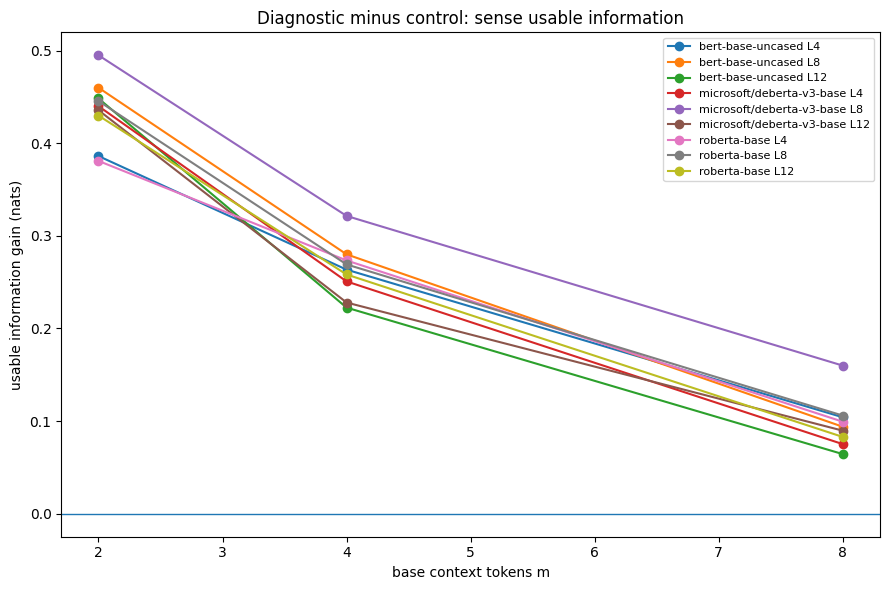

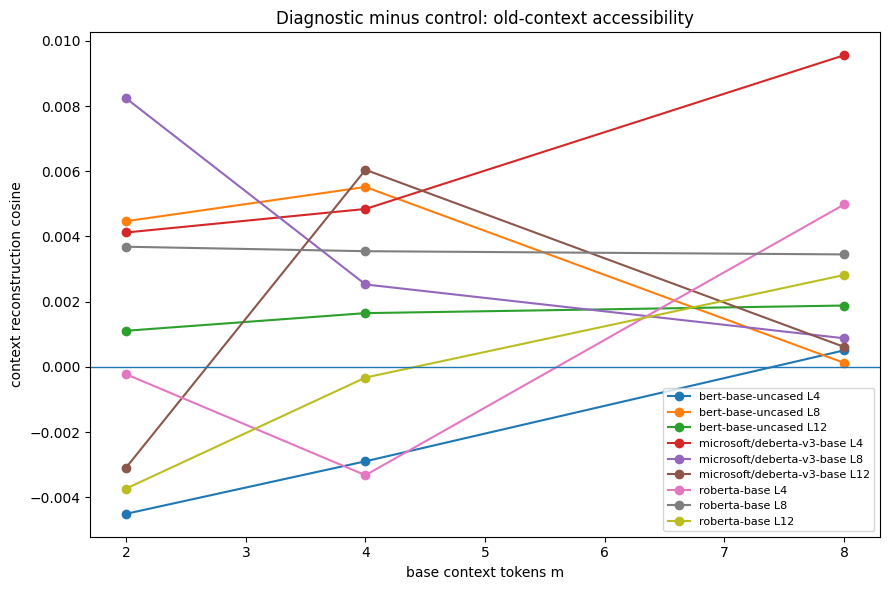

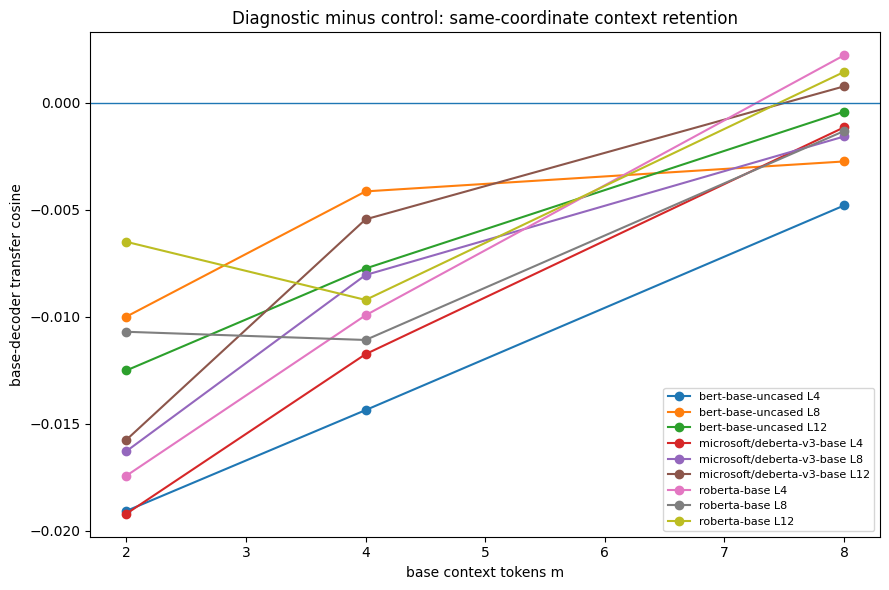

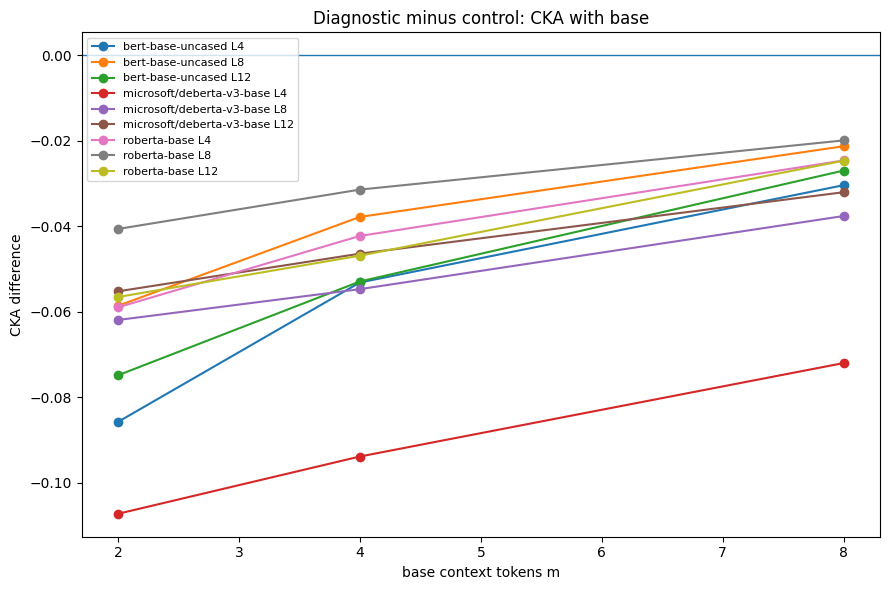

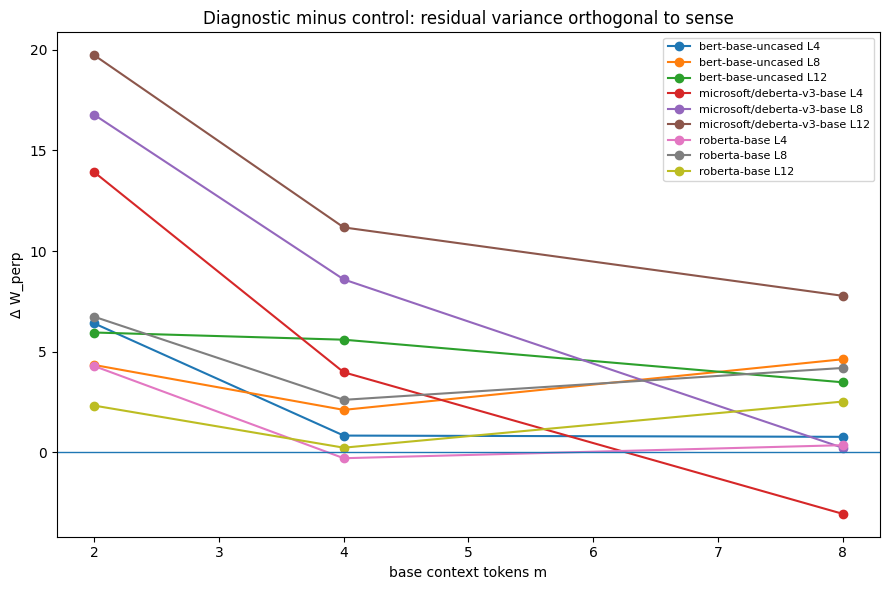

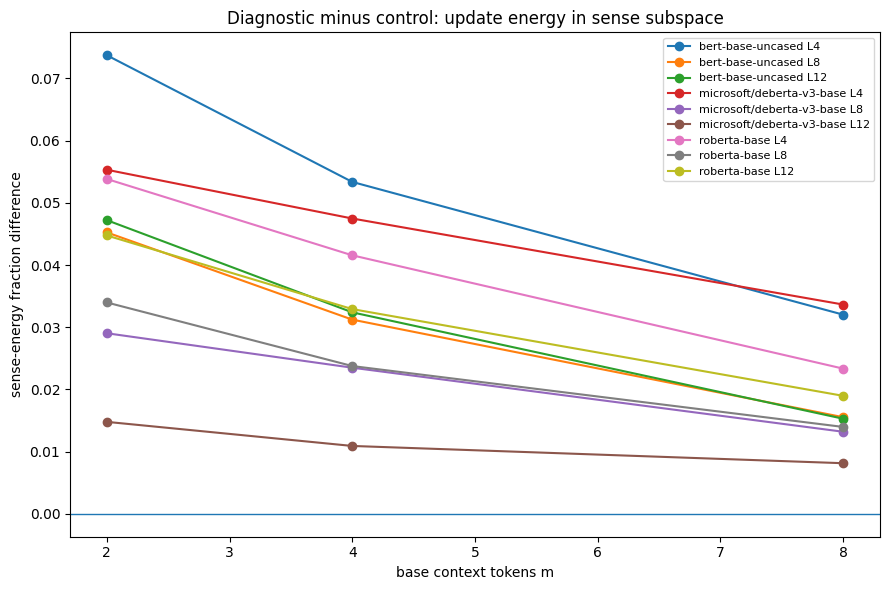

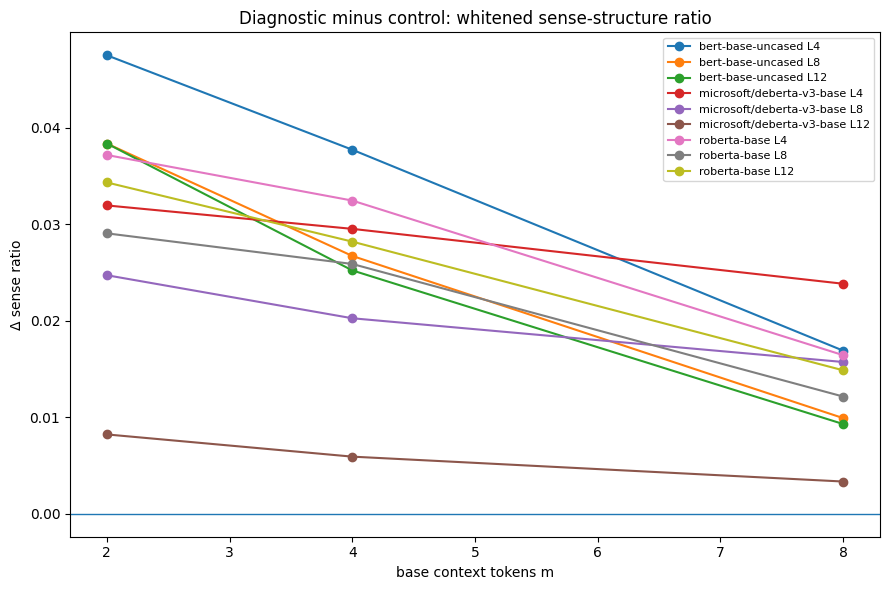

In [22]:
def aggregate_for_plot(df, metric, filters=None):
    x = df.copy()
    if filters:
        for col, val in filters.items(): x = x[x[col] == val]
    return x.groupby(["model", "layer", "base_m"])[metric].mean().reset_index()

PLOTS = [
    (sense_effects, "usable_info_nats__diag_minus_ctrl", None, "Diagnostic minus control: sense usable information", "usable information gain (nats)", "01_sense_usable_info.png"),
    (context_effects, "context_cosine__diag_minus_ctrl", None, "Diagnostic minus control: old-context accessibility", "context reconstruction cosine", "02_old_context_accessibility.png"),
    (transfer_effects, "base_decoder_transfer_cosine__diag_minus_ctrl", None, "Diagnostic minus control: same-coordinate context retention", "base-decoder transfer cosine", "03_coordinate_retention.png"),
    (structure_effects, "cka_with_base__diag_minus_ctrl", {"space": "standardized"}, "Diagnostic minus control: CKA with base", "CKA difference", "04_cka_preservation.png"),
    (subspace_effects, "W_perp__diag_minus_ctrl", None, "Diagnostic minus control: residual variance orthogonal to sense", "Δ W_perp", "05_w_perp.png"),
    (subspace_effects, "update_sense_energy__diag_minus_ctrl", None, "Diagnostic minus control: update energy in sense subspace", "sense-energy fraction difference", "06_update_sense_energy.png"),
    (geometry_effects, "sense_ratio__diag_minus_ctrl", {"space": "whitened256"}, "Diagnostic minus control: whitened sense-structure ratio", "Δ sense ratio", "07_whitened_sense_ratio.png"),
]

for df, metric, filters, title, ylabel, filename in PLOTS:
    g = aggregate_for_plot(df, metric, filters)
    plt.figure(figsize=(9, 6))
    for (model, layer), gm in g.groupby(["model", "layer"]):
        gm = gm.sort_values("base_m")
        plt.plot(gm["base_m"], gm[metric], marker="o", label=f"{model} L{layer}")
    plt.axhline(0, linewidth=1); plt.xlabel("base context tokens m"); plt.ylabel(ylabel); plt.title(title); plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, bbox_inches="tight"); plt.show()

# 20. Model × layer × evidence mechanism table

In [23]:
mech = sense_effects.merge(context_effects, on=["model", "layer", "word", "base_m"], how="inner")     .merge(transfer_effects, on=["model", "layer", "word", "base_m"], how="inner")     .merge(structure_effects[structure_effects["space"] == "standardized"].drop(columns=["space"]), on=["model", "layer", "word", "base_m"], how="inner")     .merge(subspace_effects, on=["model", "layer", "word", "base_m"], how="inner")

mechanism_summary = mech.groupby(["model", "layer", "base_m"])[[
    "usable_info_nats__diag_minus_ctrl", "context_cosine__diag_minus_ctrl",
    "base_decoder_transfer_cosine__diag_minus_ctrl", "cka_with_base__diag_minus_ctrl",
    "W_perp__diag_minus_ctrl", "update_sense_energy__diag_minus_ctrl"
]].mean().reset_index()

def descriptive_label(row, tol=0.01):
    sense_gain = row["usable_info_nats__diag_minus_ctrl"]; wperp = row["W_perp__diag_minus_ctrl"]; context = row["context_cosine__diag_minus_ctrl"]
    if not np.isfinite(sense_gain) or sense_gain <= 0: return "no verified sense gain"
    if wperp < -tol:
        return "compression + context-access loss" if context < -0.005 else "selective compression"
    if wperp > tol:
        return "enrichment-compatible" if context >= -0.005 else "expansion without retention evidence"
    return "preservation-compatible" if context >= -0.005 else "reorganization / mixed"

mechanism_summary["descriptive_mechanism"] = mechanism_summary.apply(descriptive_label, axis=1)
mechanism_summary.to_csv(RESULT_DIR / "mechanism_summary_model_layer_evidence.csv", index=False)
display(mechanism_summary)

,model,layer,base_m,usable_info_nats__diag_minus_ctrl,context_cosine__diag_minus_ctrl,base_decoder_transfer_cosine__diag_minus_ctrl,cka_with_base__diag_minus_ctrl,W_perp__diag_minus_ctrl,update_sense_energy__diag_minus_ctrl,descriptive_mechanism
0,bert-base-uncased,4,2,0.386104,-0.004509,-0.019075,-0.085787,6.406058,0.073732,enrichment-compatible
1,bert-base-uncased,4,4,0.263500,-0.002898,-0.014360,-0.053164,0.833694,0.053363,enrichment-compatible
2,bert-base-uncased,4,8,0.104173,0.000505,-0.004792,-0.030398,0.771613,0.032019,enrichment-compatible
3,bert-base-uncased,8,2,0.459875,0.004467,-0.009991,-0.058621,4.340572,0.045248,enrichment-compatible
4,bert-base-uncased,8,4,0.280025,0.005516,-0.004134,-0.037823,2.110670,0.031222,enrichment-compatible
5,bert-base-uncased,8,8,0.093933,0.000123,-0.002734,-0.021284,4.625379,0.015534,enrichment-compatible
6,bert-base-uncased,12,2,0.448267,0.001106,-0.012507,-0.074878,5.955166,0.047213,enrichment-compatible
7,bert-base-uncased,12,4,0.222512,0.001647,-0.007739,-0.052934,5.598295,0.032392,enrichment-compatible
8,bert-base-uncased,12,8,0.064430,0.001880,-0.000404,-0.026970,3.482326,0.015286,enrichment-compatible
9,microsoft/deberta-v3-base,4,2,0.439968,0.004121,-0.019208,-0.107282,13.918426,0.055321,enrichment-compatible


# 21. Stop / go criteria

Do **not** upgrade the story unless:

- diagnostic cues improve sense accessibility over all three matched controls;
- sense differentiation survives raw/standardized/whitened geometry;
- `W ≈ constant` is never called preservation without CKA/RSA + old-context accessibility;
- contraction becomes mechanistic only if \(W_\perp\) falls more than control;
- expansion becomes enrichment only if old-context accessibility is maintained/improved.

If model labels flip across layers, follow the layer × evidence trajectory instead.

# 22. Headline effects to inspect first

In [24]:
headline_metrics = [
    "usable_info_nats__diag_minus_ctrl", "context_cosine__diag_minus_ctrl",
    "base_decoder_transfer_cosine__diag_minus_ctrl", "cka_with_base__diag_minus_ctrl",
    "W_perp__diag_minus_ctrl", "update_sense_energy__diag_minus_ctrl",
    "sense_ratio__diag_minus_ctrl",
]
headline = bootstrap_summary[bootstrap_summary["metric"].isin(headline_metrics)].copy()
headline.to_csv(RESULT_DIR / "headline_effects.csv", index=False)
display(headline.sort_values(["table", "model", "layer", "base_m", "metric"]))

,table,model,layer,base_m,metric,mean_effect,ci95_low,ci95_high,wilcoxon_p,n_words,positive_fraction,space
405,context_effects,bert-base-uncased,4,2,context_cosine__diag_minus_ctrl,-0.004509,-0.010720,0.001775,0.210117,19,0.421053,NaN
408,context_effects,bert-base-uncased,4,4,context_cosine__diag_minus_ctrl,-0.002898,-0.009285,0.003322,0.465317,19,0.368421,NaN
411,context_effects,bert-base-uncased,4,8,context_cosine__diag_minus_ctrl,0.000505,-0.004322,0.005090,0.768005,19,0.578947,NaN
414,context_effects,bert-base-uncased,8,2,context_cosine__diag_minus_ctrl,0.004467,-0.001413,0.010573,0.168793,19,0.684211,NaN
417,context_effects,bert-base-uncased,8,4,context_cosine__diag_minus_ctrl,0.005516,-0.000083,0.011364,0.104156,19,0.736842,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
552,transfer_effects,roberta-base,8,4,base_decoder_transfer_cosine__diag_minus_ctrl,-0.011080,-0.017296,-0.005206,0.002838,19,0.105263,NaN
555,transfer_effects,roberta-base,8,8,base_decoder_transfer_cosine__diag_minus_ctrl,-0.001311,-0.005919,0.003068,0.738091,19,0.473684,NaN
558,transfer_effects,roberta-base,12,2,base_decoder_transfer_cosine__diag_minus_ctrl,-0.006491,-0.015852,0.002184,0.225323,19,0.368421,NaN
561,transfer_effects,roberta-base,12,4,base_decoder_transfer_cosine__diag_minus_ctrl,-0.009208,-0.017142,-0.001327,0.044559,19,0.263158,NaN


# 23. LEACE is intentionally deferred

Do not erase sense information yet. First establish that a real retention/compression/enrichment difference survives the nested controls above. If it does, a follow-up can apply LEACE or another covariance-aware concept eraser and measure collateral loss of base-context accessibility. That is the right point to make a causal entanglement claim.

# 24. Save metadata and package results

In [25]:
train_sampling.to_csv(RESULT_DIR / "train_sampling.csv", index=False)
test_sampling.to_csv(RESULT_DIR / "test_sampling.csv", index=False)
raw_counts.to_csv(RESULT_DIR / "raw_dataset_counts_after_context_filter.csv", index=False)
config = {
    "profile": PROFILE, "dataset": DATASET_ID, "eligible_words": VALID_WORDS, "models": MODELS,
    "layers": LAYERS, "base_sizes": BASE_SIZES, "control_seeds": CONTROL_SEEDS, "base_seed": BASE_SEED,
    "max_train_per_sense": MAX_TRAIN_PER_SENSE, "max_test_per_sense": MAX_TEST_PER_SENSE,
    "min_train_per_sense": MIN_TRAIN_PER_SENSE, "min_test_per_sense": MIN_TEST_PER_SENSE,
    "min_context_positions": MIN_CONTEXT_POSITIONS, "tfidf_svd_dim": TFIDF_SVD_DIM,
    "whiten_dim": WHITEN_DIM, "bootstrap_iters": BOOTSTRAP_ITERS, "eigen_layers": EIGEN_LAYERS, "seed": SEED,
}
with open(RESULT_DIR / "config.json", "w") as f: json.dump(config, f, indent=2)
print("RESULT FILES")
for p in sorted(RESULT_DIR.iterdir()): print(" ", p.name)
print("\nPLOTS")
for p in sorted(PLOT_DIR.iterdir()): print(" ", p.name)

RESULT FILES
  base_context_accessibility_control_collapsed.csv
  base_context_accessibility_per_word.csv
  base_decoder_cross_condition_transfer.csv
  base_decoder_transfer_control_collapsed.csv
  bootstrap_summary_over_words.csv
  config.json
  context_effects.csv
  covariance_geometry_control_collapsed.csv
  covariance_geometry_per_word.csv
  eigen_effects.csv
  geometry_effects.csv
  headline_effects.csv
  manipulation_added_pmi.csv
  mechanism_summary_model_layer_evidence.csv
  raw_dataset_counts_after_context_filter.csv
  sense_accessibility_control_collapsed.csv
  sense_accessibility_per_word.csv
  sense_effects.csv
  sense_subspace_redistribution_control_collapsed.csv
  sense_subspace_redistribution_per_word.csv
  structural_preservation_control_collapsed.csv
  structural_preservation_per_word.csv
  structure_effects.csv
  subspace_effects.csv
  test_sampling.csv
  train_sampling.csv
  transfer_effects.csv
  within_sense_eigenspectrum_control_collapsed.csv
  within_sense_eigens

In [26]:
# Package results + plots only. Large embedding caches stay on Kaggle.
export_dir = ROOT / "resource_export"; export_dir.mkdir(exist_ok=True)
for src_dir in [RESULT_DIR, PLOT_DIR]:
    dst = export_dir / src_dir.name
    if dst.exists(): shutil.rmtree(dst)
    shutil.copytree(src_dir, dst)
archive = shutil.make_archive("semantic_disambiguation_geometry_v4_nested_results", "zip", root_dir=export_dir)
print("RESULT ARCHIVE:", archive)
print("Embedding caches remain under:", CACHE_DIR)

RESULT ARCHIVE: /kaggle/working/semantic_disambiguation_geometry_v4_nested_results.zip
Embedding caches remain under: semantic_disambiguation_geometry_v4_nested/cache


# What would count as the most interesting result?

The cleanest result may **not** be three fixed architecture personalities. A stronger finding could be a shared trajectory that models traverse at different depths/evidence levels:

\[
\boxed{
\text{enrichment}\rightarrow\text{sense differentiation}\rightarrow\text{selective stabilization}
}
\]

V4 therefore preserves the full layer × evidence grid. If the simple BERT/RoBERTa/DeBERTa story dies but a coherent \(G(\ell,m)\) trajectory appears, follow the data.